## Summary

This vignette showcases the ability of FRAPPPE to reproduce previously reported flux ratios for E. coli under aerobic conditions. 

The experimental data originates from Fischer and Sauer, 2003 (https://doi.org/10.1046/j.1432-1033.2003.03448.x) and focuses on reproducing the flux ratio results from Kogadeeva and Zamboni, 2016 (https://doi.org/10.1371/journal.pcbi.1005109)

This vignette reproduces Figure 1B, 1C, as well as Figures S1 and S2 of the manuscript.

In [23]:
from freeflux import Model, Metabolite, Reaction

from mfa import (
    replace_uptake_reaction, 
    make_bounds, 
    sample_fluxes, 
    shuffle_labeling_pattern,
    get_mdv_dict, 
    carb_exch, 
    get_mdv_results_from_simulations, 
    calc_net_fluxes, 
    build_flux_ratios, 
    calc_ratios_from_sims, 
    plot_flux_ratios, 
    sample_ratio_specific_fluxsets, 
    get_flux_ratio, 
    get_flux_ratio_wide, 
    eval_RF_sim_pred, 
    get_reconex_fluxes, 
    train_rf
)

import re
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import joblib
from scipy.io import loadmat
import numpy as np
from matplotlib.pyplot import figure
import multiprocessing as mp


# load read sumoflux data

def expand_metabolite_name(name):
    """
    Expand a metabolite name like 'OAA14' into
    ['OAA14_m0', 'OAA14_m1', ..., 'OAA14_mN']
    where N = (d2 - d1) + 1
    """
    match = re.match(r"(.+?)(\d)(\d)$", name)
    if not match:
        raise ValueError(f"Unexpected metabolite format: {name}")

    base, d1, d2 = match.groups()
    d1, d2 = int(d1), int(d2)

    n = (d2 - d1) + 2
    return [f"{name}_m{i}" for i in range(n)]


def matmdvs_to_pd(path_to_mat):
    
    mat = loadmat(path_to_mat)
    
    colnames = [
        x[0] for x in mat["experimentalStrains"].ravel()
    ]

    rownames = [
        x[0] for x in mat["metabolites_measured"].ravel()
    ]
    
    expanded_rownames = []
    for r in rownames:
        expanded_rownames.extend(expand_metabolite_name(r))

    # rename OGA (oxoglutaric acid) to AKG (alpha-ketoglutarate) --> more canonical
    
    expanded_rownames = [re.sub("OGA", "AKG", x) for x in expanded_rownames]
    expanded_rownames = [re.sub("PYR", "Pyr", x) for x in expanded_rownames]

    data = pd.DataFrame(
        mat["experimentalData"], index = expanded_rownames, columns = colnames
    )    
    
    return(data)

def load_inputs(sim_dir, name, labeling_strat): 

    fluxes = pd.read_csv(sim_dir + name + "_fluxes.csv",index_col="Unnamed: 0")
    mdvs = pd.read_csv(sim_dir + name + "_mdvs_" + labeling_strat + "_wnoise_filtered.csv",index_col="Unnamed: 0")    
    return fluxes, mdvs

def train_rf_for_all_flux_ratios(sim_dir, flux_ratios, labeling_strat):

    input_args = [
        (
            fluxes, 
            mdvs,
            name, 
            *ratio, 
            0.3
        ) for name, ratio in flux_ratios.items() 
        for fluxes, mdvs in [load_inputs(sim_dir, name, labeling_strat)]
    ]

    with mp.Pool(3) as p:
        res = p.starmap(train_rf, input_args)
    
    res_dict = {name: ind_res for (_, _, name, _, _, _), ind_res in zip(input_args, res)}
    
    return res_dict

def xy_line(axes, ls="--", color="black", **kwargs):
    x0, x1 = axes.get_xlim()
    y0, y1 = axes.get_ylim()
    axes.plot(*[[min(x0, y0), max(x1, y1)]] * 2, ls=ls, color=color, **kwargs)

def plot_rf_results(
    results_dict, col_wrap=2, sharex=False, sharey=False, height=5, **kwargs
):
    df_pred_sim = pd.concat(
        [
            results[2].assign(flux_ratio_name=fr_name)
            for fr_name, results in results_dict.items()
        ],
        ignore_index=True,
    )

    fg = sns.FacetGrid(
        df_pred_sim,
        col="flux_ratio_name",
        col_wrap=col_wrap,
        sharex=sharex,
        sharey=sharey,
        height=height,
        **kwargs,
    ).map_dataframe(
        sns.scatterplot,
        x="simulation",
        y="prediction",
    )
    for fr_name, ax in fg.axes_dict.items():
        scores = results_dict[fr_name][1]
        ax.text(
            0.05,
            0.93,
            f"MAE: {scores['mae']:.2f}",
            fontsize=21,
            color="black",
            transform=ax.transAxes,
        )
        ax.set_xticks([0, 0.5, 1])
        ax.set_yticks([0, 0.5, 1])
        ax.tick_params(labelsize = 20)
        ax.set_xlabel("Simulation", fontsize = 21)
        ax.set_ylabel("Prediction", fontsize = 21)
        xy_line(ax)

    fg.figure.subplots_adjust(wspace = 0.3, hspace=0.3)
        
    return fg


def predict_interval(model, X, lower=5, upper=95):
    # Collect predictions from all individual trees
    tree_preds = np.array([tree.predict(X) for tree in model.estimators_])
    # tree_preds shape: (n_estimators, n_samples)
    
    lower_bound = np.percentile(tree_preds, lower, axis=0)
    upper_bound = np.percentile(tree_preds, upper, axis=0)
    point_pred  = np.mean(tree_preds, axis=0)
    
    return point_pred, lower_bound, upper_bound

def get_rf_pred_results(rf_dict, df_exp, condition, q_lower=10, q_upper=90, replace_w_nans=True):
    pred_df = (
        pd.DataFrame([
            [
                condition, 
                ratio_name, 
                *predict_interval(ratio_res[0], df_exp.sort_values("isot_model_name").query("isot_model_name in @ratio_res[0].feature_names_in_.tolist()").mdv.to_frame().transpose().values, q_lower, q_upper), 
                *ratio_res[1].values()
            ] 
            for ratio_name, ratio_res in rf_dict.items()
        ], columns=(
            "condition", 
            "flux_ratio", 
            "pred", 
            "pred_q10", 
            "pred_q90",
            "mae", 
            "cv_mae_mean", 
            "cv_mae_sd"
        ))
        .explode(["pred", "pred_q10", "pred_q90"])
        .pipe(lambda x: x.join(x.flux_ratio.str.extract(r"(?P<nucleoside>.*)_(?P<flux_ratio_name>.*)")))
    )
    
    if replace_w_nans and df_exp.mdv.isna().any():
        pred_df = pred_df.assign(pred=np.nan, pred_q10=np.nan, pred_q90=np.nan)
    return pred_df




In [2]:
target_emus_100_113C = {
    "OAA": [1,2], 
    "PEP": [1,2],
    "Pyr": [[1,2,3], [2,3]], 
    "BPG": [[1,2,3], [2,3],[1,2]]
}

target_emus_20_U13C = {
    "OAA": [[1,2,3,4], [2,3,4]], 
    "AKG": [2,3,4,5], 
    "PEP": [[1,2,3],[2,3],[1,2]],
    "Pyr": [[1,2,3],[2,3]], 
    "BPG": [1,2,3]
}

# load labeling data from Ecoli experiments


measured_20_U13C = matmdvs_to_pd("../Data/Ecoli_aerobic/SUMOFLUXexperimentalData_ECOLI20U13C.mat")
measured_100_113C = matmdvs_to_pd("../Data/Ecoli_aerobic/SUMOFLUXexperimentalData_ECOLI113C.mat")

# Arrange and re-structure input data

new_index = [r
     .replace("OAA12_m", "OAA_12_")
     .replace("PEP12_m", "PEP_12_")
     .replace("Pyr13_m", "Pyr_123_")
     .replace("Pyr23_m", "Pyr_23_")
     .replace("BPG13_m", "BPG_123_")
     .replace("BPG12_m", "BPG_12_")
     .replace("BPG23_m", "BPG_23_") 
    for r in measured_100_113C.index
]
measured_100_113C.index = new_index
measured_100_113C_sorted = measured_100_113C.sort_index().copy()


new_index = [r
             .replace("OAA14_m", "OAA_1234_")
             .replace("OAA24_m", "OAA_234_")
             .replace("AKG25_m", "AKG_2345_")
             .replace("PEP13_m", "PEP_123_")
             .replace("PEP23_m", "PEP_23_")
             .replace("PEP12_m", "PEP_12_")
             .replace("Pyr13_m", "Pyr_123_")
             .replace("Pyr23_m", "Pyr_23_")
             .replace("BPG13_m", "BPG_123_") for r in measured_20_U13C.index]

measured_20_U13C.index = new_index
measured_20_U13C_sorted = measured_20_U13C.sort_index().copy()


flux_ratios_dict = {
    "glycolysis_PPP": (["pgi"], ["pgi", "zwf"]),
    "pyruvate_from_ED": (["edp2"], ["edp2", "pyk", "mae"]),
    "gluconeogenesis": (["pck"], ["pck", "eno"]),
    "pyruvate_from_malic_enzyme": (["mae"], ["mae", "pyk", "edp2"]),
    "anaplerosis": (["pyc"], ["pyc", "sdh", "gs1"])
}


Glc_20_U13C = dict(
    labeled_substrate = "Glc.ex", 
    labeling_pattern = ['111111'], 
    percentage = [0.2], 
    purity = [0.994]    
)


Glc_100_113C = dict(
    labeled_substrate = "Glc.ex", 
    labeling_pattern = ['100000'], 
    percentage = [1], 
    purity = [0.994]    
)




## Double check flux distributions through comparison with old sumoflux fluxes

In [3]:
def get_sumoflux_fluxes(file_prefix):
    df_sumoflux_f = pd.read_csv(f"{file_prefix}_f.csv")
    df_sumoflux_b = pd.read_csv(f"{file_prefix}_b.csv")
    return pd.concat(
        [
            df_sumoflux_f.query("r_irreversible == 1"),
            df_sumoflux_b.query("r_irreversible == 0").assign(Row=lambda x: x.Row+"_b"),
            df_sumoflux_f.query("r_irreversible == 0").assign(Row=lambda x: x.Row+"_f")
        ],
        ignore_index=True
    )


def melt_flux_df(data, **kwargs):
    return (
        data
        .reset_index(names="reaction_id")
        .melt(id_vars="reaction_id", var_name="sim_name", value_name="flux")
        .assign(**kwargs)
    )

df_100_1_13c_sumoflux_fluxes = (
    get_sumoflux_fluxes("../Data/Ecoli_aerobic/fluxTable")
    .drop(columns=["r_equation", "r_irreversible"])
    .rename(columns={"Row": "reaction_id"})
    .set_index("reaction_id")
)



In [4]:

ecoli_model_file = "../Config/Models/Ecoli/reactions_model_inca_ecoli_corrected.tsv"
ecoli_model = Model("syn_wo_ends")
ecoli_model.read_from_file(ecoli_model_file)

stoic_mat = ecoli_model.get_total_stoichiometric_matrix() 

lb, ub = make_bounds(stoic_mat, 0, 100, specific={"glc_up": [10, 10]})


## Sample fluxes and create subsets for individual flux ratio predictors

In [5]:
p = Path("../Output/Ecoli_aerobic/ratio_specific_simulations/")
p.mkdir(parents = True, exist_ok = True)

# only execute flux simulations and their subsampling if simulations have not been performed yet

if not Path("../Output/Ecoli_aerobic/Ecoli_fluxes.csv").exists():
    
    ecoli_fluxes = sample_fluxes(stoic_mat, 100000, lb, ub, thinning = 1000, reconex = 1)

    ecoli_fluxes.to_csv("../Output/Ecoli_aerobic/Ecoli_fluxes.csv")

    sample_ratio_specific_fluxsets(
        path_to_fluxes="../Output/Ecoli_aerobic/Ecoli_fluxes.csv", 
        path_to_output_dir="../Output/Ecoli_aerobic/ratio_specific_simulations/", 
        flux_ratios_dict=flux_ratios_dict, 
        samples_per_bin=1000
    )

else: 
    print("Found simulated Ecoli fluxes, simulation and subsampling is skipped!")

    ecoli_fluxes = pd.read_csv("../Output/Ecoli_aerobic/Ecoli_fluxes.csv", index_col = "Unnamed: 0")

Found simulated Ecoli fluxes, simulation and subsampling is skipped!


In [53]:
pd.set_option('display.max_rows', None)

/tmp/ipykernel_2573606/1211250731.py:3: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(right=0.80)


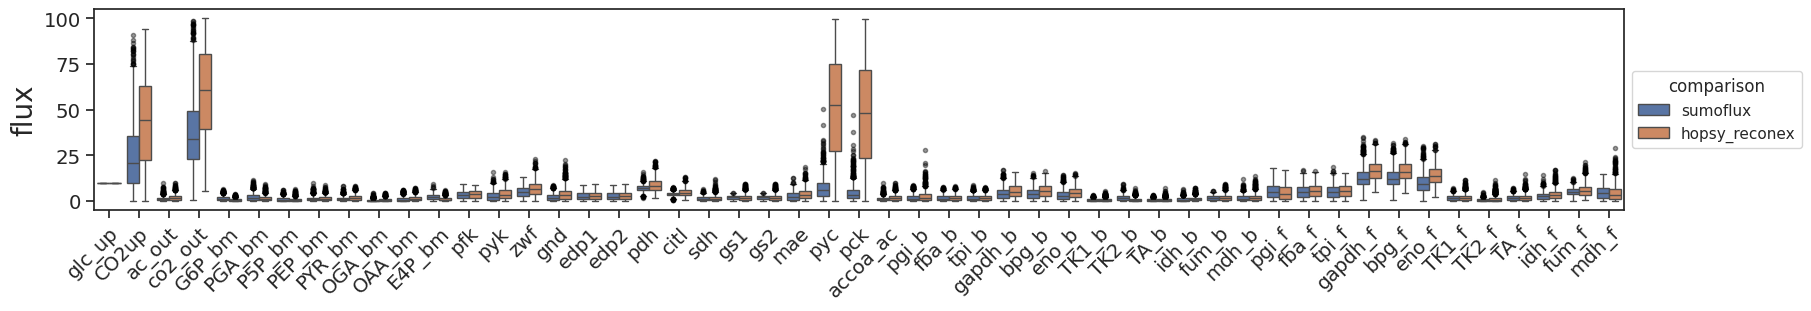

In [54]:
fig, ax = plt.subplots(figsize=(18, 3), constrained_layout=True)
# ax.set_yscale('log')
fig.subplots_adjust(right=0.80)
b = sns.boxplot(
    pd.concat([
        df_100_1_13c_sumoflux_fluxes
            .sample(1000, axis=1, random_state=42)
            .pipe(melt_flux_df, comparison="sumoflux"), 
        ecoli_fluxes
            .sample(1000, axis=1, random_state=42)
            .pipe(melt_flux_df, comparison = "hopsy_reconex")
    ]),
    x="reaction_id", 
    y="flux",
    flierprops = dict(
        marker = "o", 
        markersize = 3, 
        markerfacecolor = 'black', 
        markeredgecolor = "black",
        alpha = 0.4
        
    ),
    hue="comparison",
    dodge=True
)
b.tick_params(labelsize = 14.2)
b.set_xlabel("", fontsize = 20)
b.set_ylabel("flux", fontsize = 20)
sns.move_legend(ax, loc="center left", bbox_to_anchor=(1.0, 0.5))
ax.tick_params(axis="x", labelrotation=45)
plt.setp(ax.get_xticklabels(), ha="right", rotation_mode="anchor")
plt.savefig("../Output/Ecoli_aerobic/flux_distribution_comparison.pdf")

## Simulate mdvs for subsampled fluxes in 20% U13C Glucose condition

In [55]:
# only simulate iterations for which the simulation has not been conducted yet, saving time in re-runs

for r in flux_ratios_dict.keys():
    print(r)
    if not Path("../Output/Ecoli_aerobic/ratio_specific_simulations/" + r + "_mdvs_20_U13C.csv").exists():
        print("File does not exist, simulating mdvs")
        # read in subsampled fluxes
        fluxes_subsampled = pd.read_csv("../Output/Ecoli_aerobic/ratio_specific_simulations/" + r + "_fluxes.csv", index_col = "Unnamed: 0")
        mdvs_subsampled = get_mdv_results_from_simulations(ecoli_model, fluxes_subsampled, target_emus_20_U13C, Glc_20_U13C, parallel=8, as_df=True)
        mdvs_subsampled.columns = fluxes_subsampled.columns
        mdvs_subsampled.sort_index().to_csv("../Output/Ecoli_aerobic/ratio_specific_simulations/" + r + "_mdvs_20_U13C.csv")
    else: 
        print("simulations already conducted, going to next ratio")
        

glycolysis_PPP
File does not exist, simulating mdvs
pyruvate_from_ED
File does not exist, simulating mdvs
gluconeogenesis
File does not exist, simulating mdvs
pyruvate_from_malic_enzyme
File does not exist, simulating mdvs
anaplerosis
File does not exist, simulating mdvs


## Simulate mdvs for subsampled fluxes in 100% 1-13C Glucose condition

In [56]:
# only simulate iterations for which the simulation has not been conducted yet, saving time in re-runs

for r in flux_ratios_dict.keys():
    print(r)
    if not Path("../Output/Ecoli_aerobic/ratio_specific_simulations/" + r + "_mdvs_100_113C.csv").exists():
        print("File does not exist, simulating mdvs")
        
        # read in subsampled fluxes
        fluxes_subsampled = pd.read_csv("../Output/Ecoli_aerobic/ratio_specific_simulations/" + r + "_fluxes.csv", index_col = "Unnamed: 0")
        mdvs_subsampled = get_mdv_results_from_simulations(ecoli_model, fluxes_subsampled, target_emus_100_113C, Glc_100_113C, parallel=8, as_df=True)
        mdvs_subsampled.columns = fluxes_subsampled.columns
        mdvs_subsampled.sort_index().to_csv("../Output/Ecoli_aerobic/ratio_specific_simulations/" + r + "_mdvs_100_113C.csv")
    
    else: 
        print("simulations already conducted, going to next ratio")

glycolysis_PPP
File does not exist, simulating mdvs
pyruvate_from_ED
File does not exist, simulating mdvs
gluconeogenesis
File does not exist, simulating mdvs
pyruvate_from_malic_enzyme
File does not exist, simulating mdvs
anaplerosis
File does not exist, simulating mdvs


## Calculate labeling patterns of simulations from sumoflux and compare with mdvs directly calculated in SUMOFLUX



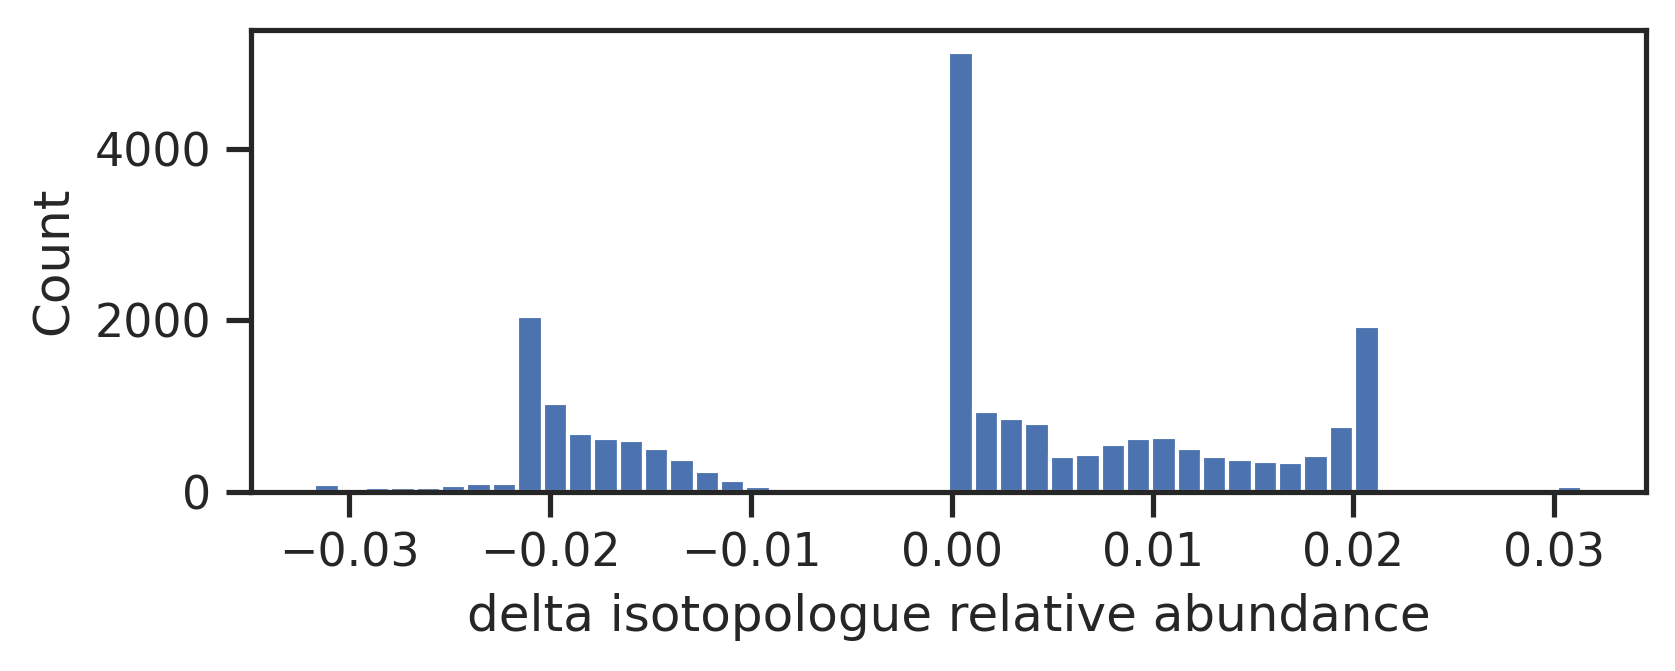

In [57]:
figure(figsize=(6, 2), dpi=300)

def convert_sumoflux_notation(metabolite):
    met, suf = metabolite.split("_", maxsplit=2)
    min_val = 1
    if suf == met:
        suf = 0

    if met[-2].isdigit():
        min_val, max_val = int(met[-2]), int(met[-1])
        new_labelling = "".join([str(x) for x in range(int(min_val), int(max_val)+1)])
        name = met[:-2]
        if suf != 0:
            suf = int(suf) - min_val + 1
    else:
        new_labelling = met[-1]
        name = met[:-1]
        if suf != 0:
            suf = 1
        
    return f"{name}_{new_labelling}_{suf}"

def get_sumoflux_fluxes(file_prefix):
    df_sumoflux_f = pd.read_csv(f"{file_prefix}_f.csv")
    df_sumoflux_b = pd.read_csv(f"{file_prefix}_b.csv")
    return pd.concat(
        [
            df_sumoflux_f.query("r_irreversible == 1"),
            df_sumoflux_b.query("r_irreversible == 0").assign(Row=lambda x: x.Row+"_b"),
            df_sumoflux_f.query("r_irreversible == 0").assign(Row=lambda x: x.Row+"_f")
        ],
        ignore_index=True
    )


def melt_flux_df(data, **kwargs):
    return (
        data
        .reset_index(names="reaction_id")
        .melt(id_vars="reaction_id", var_name="sim_name", value_name="flux")
        .assign(**kwargs)
    )



df_100_1_13c_sumoflux_fluxes = (
    get_sumoflux_fluxes("../Data/Ecoli_aerobic/fluxTable")
    .drop(columns=["r_equation", "r_irreversible"])
    .rename(columns={"Row": "reaction_id"})
    .set_index("reaction_id")
    .iloc[:,0:1000]
)



df_100_1_13c_sumoflux_mdvs = (
    pd.read_csv("../Data/Ecoli_aerobic/mdvTable.csv")
    .assign(Row=lambda x: x.Row.str.replace("PYR", "Pyr").apply(convert_sumoflux_notation))
    .set_index("Row")
    .iloc[:, 0:1000]
)


ecoli_model_file = "../Config/Models/Ecoli/reactions_model_inca_ecoli_corrected.tsv"
ecoli_model = Model("syn_wo_ends")
ecoli_model.read_from_file(ecoli_model_file)

stoic_mat = ecoli_model.get_total_stoichiometric_matrix() 

lb, ub = make_bounds(stoic_mat, 0, 100, specific={"glc_up": [10, 10]})

frapppe_mdvs = get_mdv_results_from_simulations(ecoli_model, df_100_1_13c_sumoflux_fluxes, target_emus_100_113C, Glc_100_113C, parallel=8, as_df=True)

df_100_1_13c_sumoflux_mdvs = df_100_1_13c_sumoflux_mdvs.loc[frapppe_mdvs.index].reindex(frapppe_mdvs.index)

diffs = (frapppe_mdvs.values - df_100_1_13c_sumoflux_mdvs.values).flatten()

plt.hist(diffs, bins=50)
plt.xlabel("delta isotopologue relative abundance")
plt.ylabel("Count")
plt.savefig("../Output/Ecoli_aerobic/delta_mdv_relab.pdf", bbox_inches = "tight")
plt.show()


In [58]:
abs(diffs).mean()


0.011383743840710963

## Add noise to simulated mdvs and remove low-abundant features

Adding noise of 0.01 to all mdvs prevents the predictor to learn the associations between spurious signals and flux ratio. Further, we now also remove all feats which are below 0.05 in all samples to prevent the pretictor from focussing on low-abundant signals.

In [6]:
def add_noise(data, noise_scale=0.01, seed=42):
    rng = np.random.default_rng(seed)
    new_data = (data + rng.uniform(-noise_scale, noise_scale, size=data.shape)).abs()
    return new_data / new_data.sum(axis=0) 

In [7]:
# per file, read in subset, add noise, filter low-abundant feats and write it again

flux_ratios_dict_100_113C = {k: flux_ratios_dict[k] for k in ["glycolysis_PPP", "pyruvate_from_ED", "gluconeogenesis"]}

for r in flux_ratios_dict_100_113C.keys():
    
    mdvs = pd.read_csv("../Output/Ecoli_aerobic/ratio_specific_simulations/" + r + "_mdvs_100_113C.csv", index_col = "Unnamed: 0")
    
    mdvs_wnoise = (
        mdvs
        .reset_index(names="isotopo")
        .assign(mb=lambda x: x.isotopo.str.extract("(.*_.*)_.*"))
        .set_index("isotopo")
        .groupby("mb")
        .transform(add_noise)
    )
    
    mdvs_sel = (
        mdvs_wnoise[(mdvs_wnoise > 0.05).any(axis=1)]
        .reset_index(names = "Unnamed: 0")
        .set_index("Unnamed: 0")
    )
    
    mdvs_sel.to_csv("../Output/Ecoli_aerobic/ratio_specific_simulations/" + r + "_mdvs_100_113C_wnoise_filtered.csv")



In [8]:
# per file, read in subset, add noise, filter low-abundant feats and write it again

flux_ratios_dict_20_U13C = {k: flux_ratios_dict[k] for k in ["pyruvate_from_malic_enzyme", "anaplerosis"]}

for r in flux_ratios_dict_20_U13C.keys():
    
    mdvs = pd.read_csv("../Output/Ecoli_aerobic/ratio_specific_simulations/" + r + "_mdvs_20_U13C.csv", index_col = "Unnamed: 0")
    
    mdvs_wnoise = (
        mdvs
        .reset_index(names="isotopo")
        .assign(mb=lambda x: x.isotopo.str.extract("(.*_.*)_.*"))
        .set_index("isotopo")
        .groupby("mb")
        .transform(add_noise)
    )
    
    mdvs_sel = (
        mdvs_wnoise[(mdvs_wnoise > 0.05).any(axis=1)]
        .reset_index(names = "Unnamed: 0")
        .set_index("Unnamed: 0")
    )
    
    mdvs_sel.to_csv("../Output/Ecoli_aerobic/ratio_specific_simulations/" + r + "_mdvs_20_U13C_wnoise_filtered.csv")



In [9]:
p = Path("../Output/Ecoli_aerobic/predictors_w_noise/")
p.mkdir(parents = True, exist_ok = True)

## Train random forests

In [10]:
res_dict_20_U13C = train_rf_for_all_flux_ratios(
    sim_dir = "../Output/Ecoli_aerobic/ratio_specific_simulations/", 
    flux_ratios = flux_ratios_dict_20_U13C, 
    labeling_strat = "20_U13C"
)


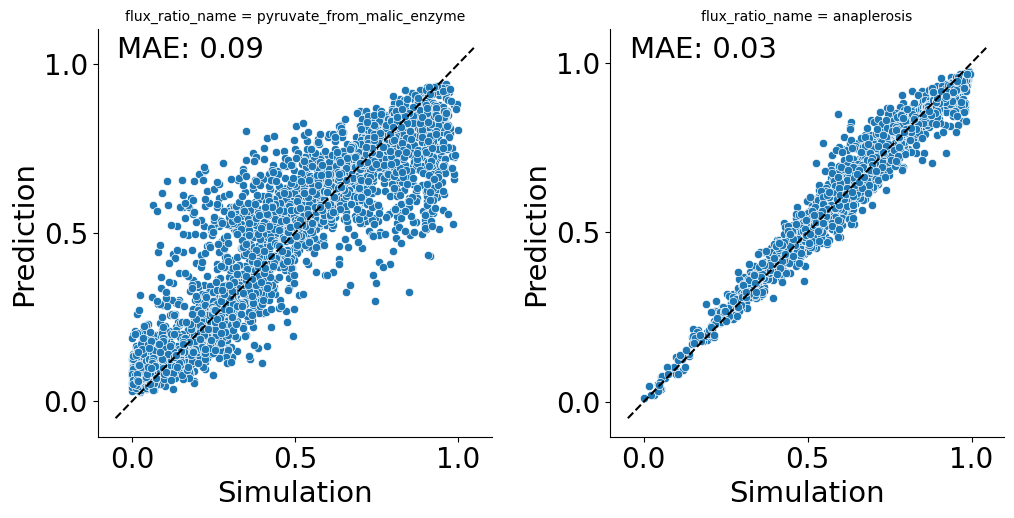

In [24]:
fg = plot_rf_results(res_dict_20_U13C, col_wrap=3)
fg.savefig("../Output/Ecoli_aerobic/predictors_w_noise/20_U13C.pdf", dpi = 300, bbox_inches="tight")

In [12]:
res_dict_100_113C = train_rf_for_all_flux_ratios(
    sim_dir = "../Output/Ecoli_aerobic/ratio_specific_simulations/", 
    flux_ratios = flux_ratios_dict_100_113C, 
    labeling_strat = "100_113C"
)


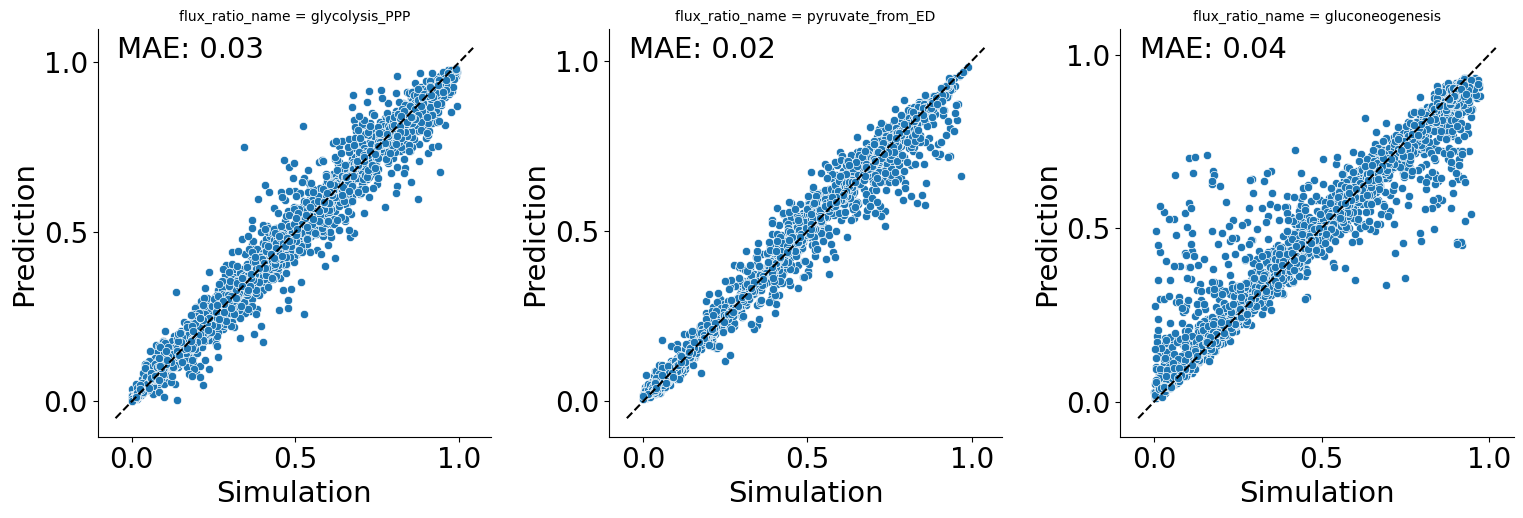

In [25]:
fg = plot_rf_results(res_dict_100_113C, col_wrap=3)
fg.savefig("../Output/Ecoli_aerobic/predictors_w_noise/100_113C.pdf", dpi = 300, bbox_inches="tight")

## Comparison of flux ratio estimates from SUMOFLUX and FRAPPPE

In [67]:
# adapt format of experimental mdvs

measured_20_U13C_rearranged = (
    measured_20_U13C.reset_index()
    .melt(
        id_vars="index",
        var_name="col_name",
        value_name="value"
    ).rename(
        columns={
            "index":"isot_model_name", 
            "col_name":"mutant",
            "value":"mean"
        }
    ).pipe(lambda x: x.join(
        x.isot_model_name.str.extract(r"(?P<mb>.*)_(?P<atomnos>.*)_(?P<m>.*)", expand=True)
    ))
    .drop(columns="atomnos")
    .assign(m=lambda x: x.m.astype(int))
    .pipe(lambda x: x.merge(
        x.groupby('mb')["m"].max().apply(lambda x: "".join([str(y) for y in range(1, x+1)])).rename("atomnos").reset_index(),
        on="mb",
        how="left"
    ))
    .assign(
        isotopo=lambda x: x.mb + "_" + x.atomnos + "_" + x.m.astype(str),
        emu=lambda x:  x.mb + "_" + x.atomnos
    )
    .rename(columns={"mean": "mdv"})   
)

measured_100_113C_rearranged = (
    measured_100_113C.reset_index()
    .melt(
        id_vars="index",
        var_name="col_name",
        value_name="value"
    ).rename(
        columns={
            "index":"isot_model_name", 
            "col_name":"mutant",
            "value":"mean"
        }
    ).pipe(lambda x: x.join(
        x.isot_model_name.str.extract(r"(?P<mb>.*)_(?P<atomnos>.*)_(?P<m>.*)", expand=True)
    ))
    .drop(columns="atomnos")
    .assign(m=lambda x: x.m.astype(int))
    .pipe(lambda x: x.merge(
        x.groupby('mb')["m"].max().apply(lambda x: "".join([str(y) for y in range(1, x+1)])).rename("atomnos").reset_index(),
        on="mb",
        how="left"
    ))
    .assign(
        isotopo=lambda x: x.mb + "_" + x.atomnos + "_" + x.m.astype(str),
        emu=lambda x:  x.mb + "_" + x.atomnos
    )
    .rename(columns={"mean": "mdv"})   
)





In [68]:
output = pd.concat([
    pd.concat([
        get_rf_pred_results(
            res_dict_20_U13C,
            measured_20_U13C_rearranged.query("mutant == @cond"),
            "Glc_20_U13C"
        ).assign(mutant = cond)
        for cond in measured_20_U13C_rearranged.mutant.unique().tolist()
    ]), 
    pd.concat([
        get_rf_pred_results(
            res_dict_100_113C,
            measured_100_113C_rearranged.query("mutant == @cond"),
            "Glc_100_113C"
        ).assign(mutant = cond)
        for cond in measured_100_113C_rearranged.mutant.unique().tolist()
    ]) 
])
output


,condition,flux_ratio,pred,pred_q10,pred_q90,mae,cv_mae_mean,cv_mae_sd,nucleoside,flux_ratio_name,mutant
0,Glc_20_U13C,pyruvate_from_malic_enzyme,0.117446,0.006635,0.192478,0.091723,-0.094170,0.002445,pyruvate_from_malic,enzyme,WT
1,Glc_20_U13C,anaplerosis,0.635919,0.523877,0.707741,0.033358,-0.034426,0.000445,NaN,NaN,WT
0,Glc_20_U13C,pyruvate_from_malic_enzyme,0.082539,0.006635,0.157406,0.091723,-0.094170,0.002445,pyruvate_from_malic,enzyme,zwf
1,Glc_20_U13C,anaplerosis,0.439824,0.335196,0.543525,0.033358,-0.034426,0.000445,NaN,NaN,zwf
0,Glc_20_U13C,pyruvate_from_malic_enzyme,0.28166,0.043939,0.737473,0.091723,-0.094170,0.002445,pyruvate_from_malic,enzyme,pgi
1,Glc_20_U13C,anaplerosis,0.470633,0.346735,0.588009,0.033358,-0.034426,0.000445,NaN,NaN,pgi
0,Glc_20_U13C,pyruvate_from_malic_enzyme,0.158015,0.018635,0.311677,0.091723,-0.094170,0.002445,pyruvate_from_malic,enzyme,pfkA
1,Glc_20_U13C,anaplerosis,0.528771,0.423409,0.61383,0.033358,-0.034426,0.000445,NaN,NaN,pfkA
0,Glc_20_U13C,pyruvate_from_malic_enzyme,0.184905,0.067785,0.296325,0.091723,-0.094170,0.002445,pyruvate_from_malic,enzyme,pykAF
1,Glc_20_U13C,anaplerosis,0.625382,0.52736,0.687828,0.033358,-0.034426,0.000445,NaN,NaN,pykAF


In [69]:

mzk2016 = pd.read_csv("../Data/Ecoli_aerobic/flux_ratios_kogadeeva_2016.csv")

mzk2016_long = mzk2016.melt(
    id_vars = "ratio", 
    var_name = "mutant",
    value_name = "sumoflux_ratio"
).replace(
    to_replace = {"ratio": "/| "},
    value = "_", 
    regex=True
)

output_sel = output[["flux_ratio", "mutant", "pred"]].rename(columns = {"flux_ratio": "ratio", "pred": "FRAPPPE_pred"})

def clean(x):
    x = str(x)
    x = x.strip()
    return x

mzk2016_long["mutant"] = mzk2016_long["mutant"].apply(clean)
output_sel["mutant"] = output_sel["mutant"].apply(clean)

comp = mzk2016_long.merge(output_sel, how = "outer", on = ["ratio", "mutant"])

comp.to_csv("../Output/Ecoli_aerobic/predictors_w_noise/comparison.csv")

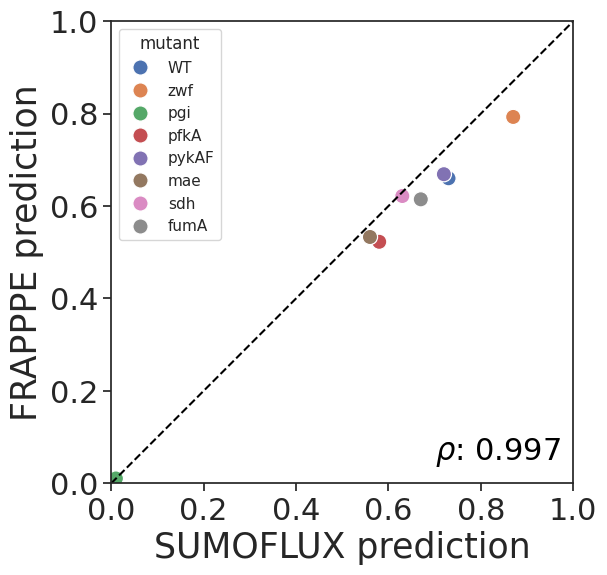

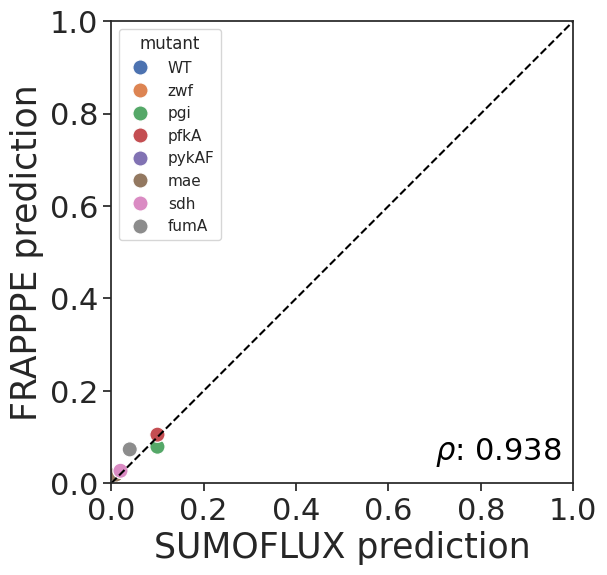

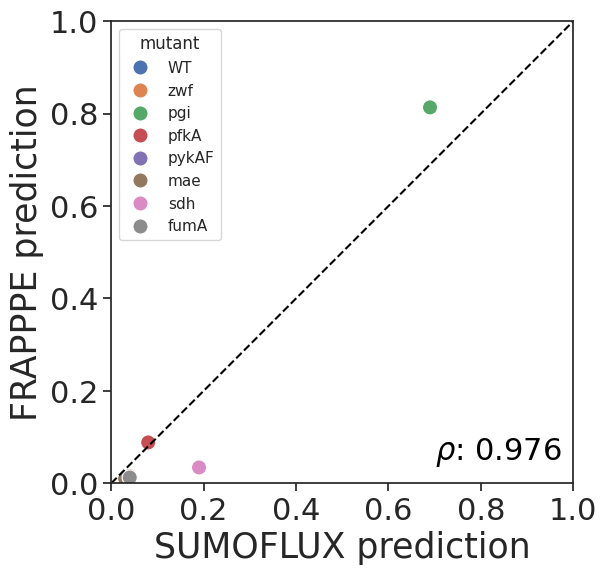

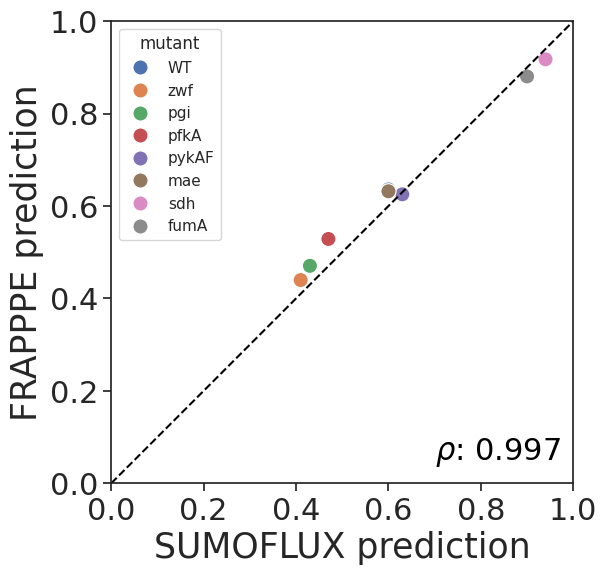

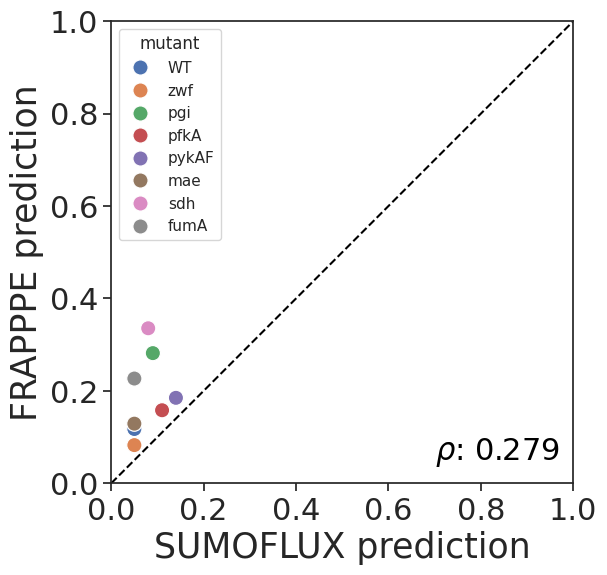

In [70]:
comp["FRAPPPE_pred"] = comp["FRAPPPE_pred"].astype(float)

sns.set_theme(
    rc={"figure.figsize": (6, 6)},
    style="ticks"  
)

for i in comp.loc[:, "ratio"].unique(): 
    df_sub = comp.query("ratio == @i")
    a = pd.Series(df_sub.loc[:, "sumoflux_ratio"])
    b = pd.Series(df_sub.loc[:, "FRAPPPE_pred"])
    pearson = a.corr(b).round(3)

    fig, ax = plt.subplots()
    
    sns.scatterplot(
        data = df_sub,
        x = "sumoflux_ratio", 
        y = "FRAPPPE_pred", 
        hue="mutant",
        s=120
    )

    ax.text(0.7, 0.05, r'$\rho$' + ": " + str(pearson), fontsize=22, color="black")
    ax.set(xlim=(0, 1), ylim=(0, 1))
    ax.set_aspect('equal', adjustable='box')  
    ax.tick_params(labelsize = 22)
    ax.set_xlabel("SUMOFLUX prediction", fontsize = 25)
    ax.set_ylabel("FRAPPPE prediction", fontsize = 25)
    ax.axline((0, 0), slope=1, color='black', linestyle = "--")
    plt.savefig("../Output/Ecoli_aerobic/predictors_w_noise/sumoflux_vs_hopsy_reconstrained_" +  i + ".pdf", bbox_inches = "tight")
